# Homework 4

**Note: Do not run the image display cells.** 

Acamaro Cutcher


### Problem 1 Approximation errors

**a)** Consider the integral

$$
I=\int_0^1\sin^2(10x)dx.
$$

Using the trapezoidal rule, calculate the number of slices $N$ required to reduce the approximation error to the rounding error. You will need to know the approximate value of the integral which you don't know yet. To estimate, plot the integrand over the integration interval and estimate the area from your graph. Provide your estimate of the area then use it to calculate $N$. 

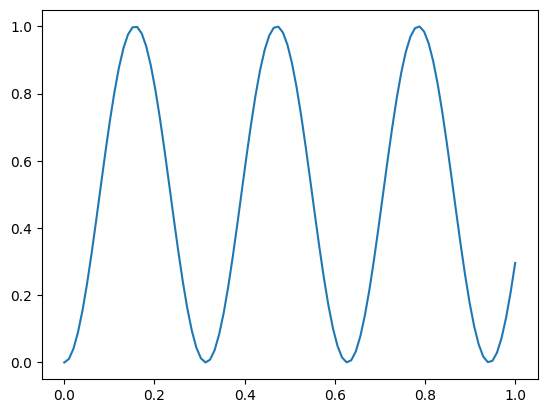

In [1]:
# Problem 1a code
import matplotlib.pyplot as plt
import numpy as np

def func(x):
    return np.power(np.sin(10*x),2)

x_array = np.linspace(0,1, 100)
y_array = func(x_array)
plt.plot(x_array, y_array)
plt.show()

**Your estimate of the integral: 0.5**


**Add your calculation of $N$ (show work) in this cell.** 
See that our function 
$$
f(x) = \sin^2(10 \cdot x) 
$$
has as it's derivative:
$$
f'(x) = 20 \cdot \sin(10\cdot x) \cdot \cos(10 \cdot x)
$$

From the Euler-Macclaurin Formula for the error on the trapezoidal rule:
$$
\epsilon = \frac{h^2}{12} ( f'(a) - f'(b)) 
$$

we can find the largest $N$ when the trapezoidal error equals the rounding error on the interval we estimate with the TR:

$$
\text{approximation error} = \text{rounding error}
$$

$$
\frac{h^2}{12}\left(f'(a) - f'(b)\right) = C\int_{a}^{b}f(x)dx
$$

Solving for $N$ we have:

$$
N = (b-a) \cdot \sqrt{\frac{f'(a) -f'(b)}{12 \cdot \int_a^b f(x) dx}} C^{-1/2}
$$

Now we replace the values of $C = 10^{-16}$, and $a=0$ and $b=1$ to give us: 

$$
N = (1) \cdot \sqrt{\frac{f'(0) -f'(1)}{12 \cdot \int_0^1 f(x) dx}} 10^{8}
$$

Given my approximation for the integral $\int_0^1 f(x) dx = 0.5$ we can find the approximate value for $N$ to reduce the approximation error to the rounding error. 

$$
N = (1) \cdot \sqrt{\frac{f'(0) -f'(1)}{12 \cdot 0.5}} 10^{8}
$$

Finally to find $N$, we evaluate our function's derivative at $x=0$ and $x=1$ to get: $$f'(0) = 20 \cdot \sin(10\cdot 0) \cdot \cos(10 \cdot 0) = 0$$ 
and $$f'(1) = 20 \cdot \sin(10) \cdot \cos(10) =9.129$$.

$$
N = \sqrt{\frac{9.129}{12 \cdot 0.5}} 10^{8} = 123349098.09155476 \approx 10^{8}
$$

**Pts /10**

**b)**  Use the trapezoid rule to estimate the integral and approximation error over a range of $N$ up to the number of slices you calculated in part a).  

$$
I=\int_0^1\sin^2(10x)dx.
$$

Evaluate the approximation two ways:
1. Using the *Euler-Maclaurin formula*.
2. Using the "doubling" method where you estimate the integral a second time using $2N$.

Make two plots.
1. A plot of $I$ vs $N$.
2. A plot of both errors vs. $N$.

Consider using log scales where needed.  

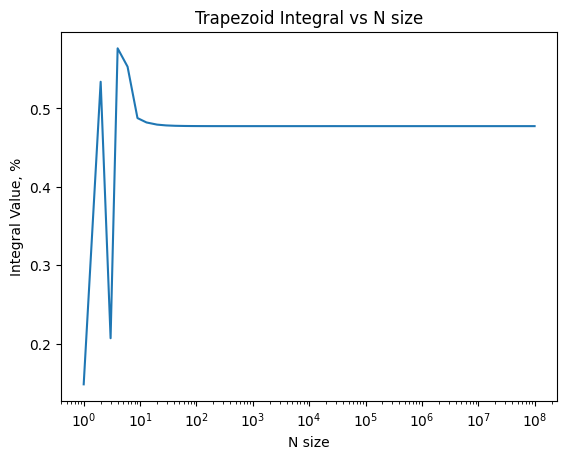

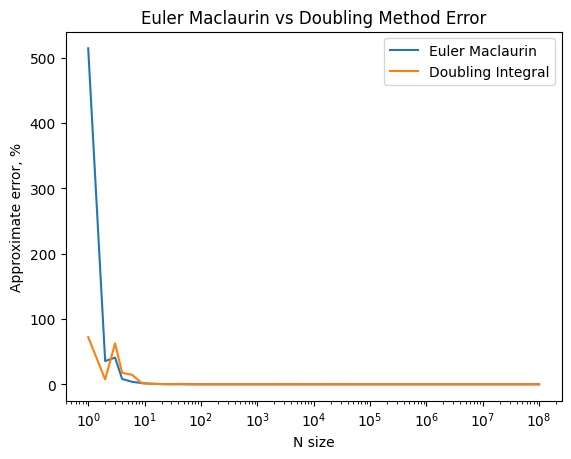

In [28]:
# Problem 1b code
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return np.sin(10*x)**2

def f_1(x):
    return 20 * np.sin(10*x) * np.cos(10*x)

def trapezoidR(f,a,b, N):
    """ Trapezoid Function """
    h = (b-a)/N
    total = np.sum(f(np.arange(a+h, b, h)))
    total += (f(a) + f(b))/2
    approx_int = h * total
    
    return approx_int

def euler_maclaurin(f_1, a, b, N):
    h = (b-a)/N
    return h**2/12 * (f_1(a) - f_1(b))

def doubling(f,a,b,N):
    """ Trapezoid Function """
    N = 2 * N
    h = (b-a)/N
    total = np.sum(f(np.arange(a+h, b, h)))
    total += (f(a) + f(b))/2
    approx_int = h * total
    
    return approx_int 

# Plot I vs N

N_range = np.logspace(0, 8, num=50, dtype=int) 
I_range = np.array([trapezoidR(f, 0, 1, n) for n in N_range])

plt.plot(N_range, I_range)
plt.title("Trapezoid Integral vs N size")
plt.xscale('log')
plt.xlabel("N size")
plt.ylabel("Integral Value, %")
plt.show()


# Plot both errors vs N

e_error = np.array([euler_maclaurin(f_1, 0,1,n) for n in N_range])
I2_range = np.array([doubling(f,0,1,n) for n in N_range])

percent_error_e_error = np.abs(100 * e_error/I_range)
percent_error_I2_range = np.abs(100 * (I2_range - I_range)/I2_range)

plt.plot(N_range, percent_error_e_error, label="Euler Maclaurin")
plt.plot(N_range, percent_error_I2_range, label="Doubling Integral")
plt.legend()
plt.title("Euler Maclaurin vs Doubling Method Error")
plt.xscale('log')
plt.xlabel("N size")
plt.ylabel("Approximate error, %")
plt.show()



**Pts /10**

#### Problem 1 Pts /20

## Problem 2 Quantum uncertainty in the harmonic oscillator
This is Exercise 5.13. If the images below do not appear, either consult the textbook or view the PDF of the problem on Canvas in the Homework module.  

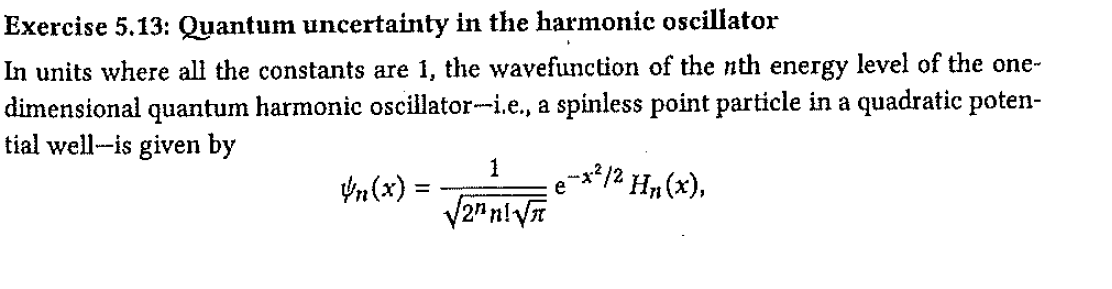

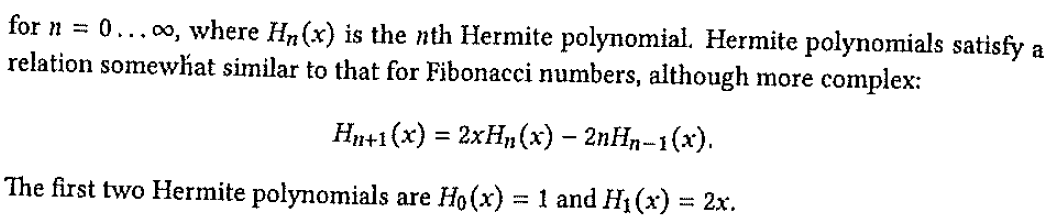

In [5]:
from IPython.display import Image, display
display(Image("G:\\My Drive\\Classes\\Ph322\\2026\\Homework\\Figures\\ex5.13_intro1.png"))
display(Image("G:\\My Drive\\Classes\\Ph322\\2026\\Homework\\Figures\\ex5.13_intro2.png"))


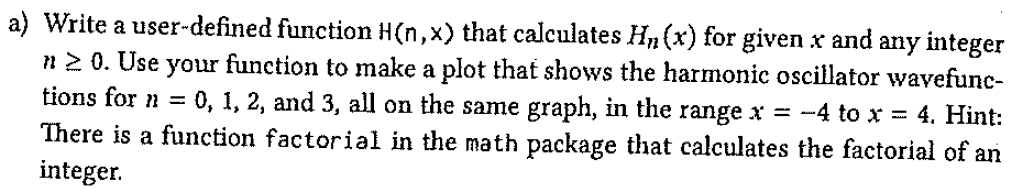

In [6]:
from IPython.display import Image, display
display(Image("G:\\My Drive\\Classes\\Ph322\\2026\\Homework\\Figures\\ex5.13_parta.png"))

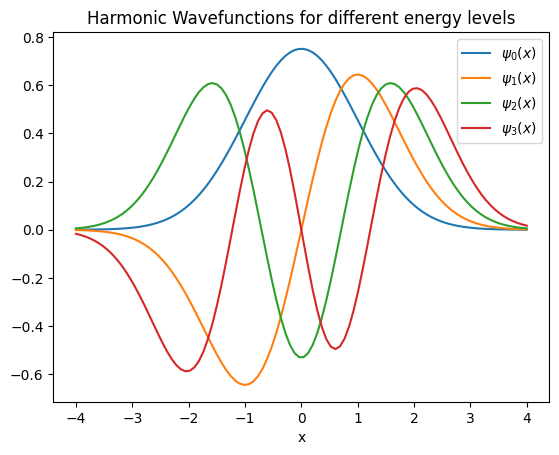

In [ ]:
# Enter Exercise 5.13a code 
import numpy as np
import matplotlib.pyplot as plt
from math import factorial

def H(n, x):
    if n == 0:
        return 1
    if n == 1:
        return 2*x
    else: 
        return 2*x*H(n-1,x)-2*(n-1)*H(n-2, x)

def psi(n,x):
    coefficient = 1 / np.sqrt(np.power(2,n) * factorial(n) * np.sqrt(np.pi))  
    exp_val = np.exp(-x**2/2)
    hermite_val = H(n,x)
    return coefficient * exp_val * hermite_val

def display_h():
    x_range = np.linspace(-4,4,100, endpoint=True)
    
    psi0 = np.array([psi(0,x_step) for x_step in x_range])
    psi1 = np.array([psi(1,x_step) for x_step in x_range])
    psi2 = np.array([psi(2,x_step) for x_step in x_range])
    psi3 = np.array([psi(3,x_step) for x_step in x_range])
    
    plt.plot(x_range, psi0, label=r"$\psi_0(x)$")
    plt.plot(x_range, psi1, label=r"$\psi_1(x)$")
    plt.plot(x_range, psi2, label=r"$\psi_2(x)$")
    plt.plot(x_range, psi3, label=r"$\psi_3(x)$")
    plt.title("Harmonic Wavefunctions for different energy levels")
    plt.xlabel("x")
    plt.legend()
    plt.show()

display_h()

**Pts /10**

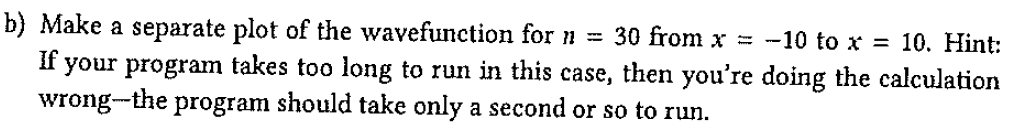

In [8]:
from IPython.display import Image, display
display(Image("G:\\My Drive\\Classes\\Ph322\\2026\\Homework\\Figures\\ex5.13_partb.png"))

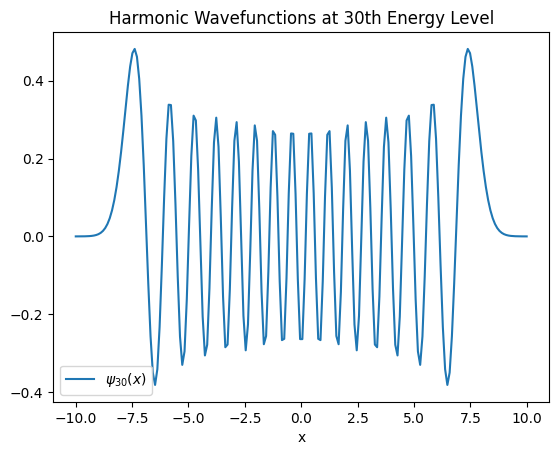

In [27]:
# Enter Exercise 5.13b code
import numpy as np
import matplotlib.pyplot as plt
from math import lgamma


def H(n, x):
    if n == 0:
        return 1
    if n == 1:
        return 2*x
    else: 
        return 2*x*H(n-1,x)-2*(n-1)*H(n-2, x)

def psi(n,x):
    log_coeff = -0.5 * (n*np.log(2) + lgamma(n+1) +0.5 * np.log(np.pi))
    coeff = np.exp(log_coeff)
    return coeff * np.exp(-x**2/2) * H(n,x)

def display_h():
    x_range = np.linspace(-10,10,200, endpoint=True)
    
    psi30 = np.array([psi(30,x_step) for x_step in x_range])

    plt.plot(x_range, psi30, label=r"$\psi_{30}(x)$")

    plt.title("Harmonic Wavefunctions at 30th Energy Level")
    plt.xlabel("x")
    plt.legend()
    plt.show()
    
display_h()

**Pts /5**

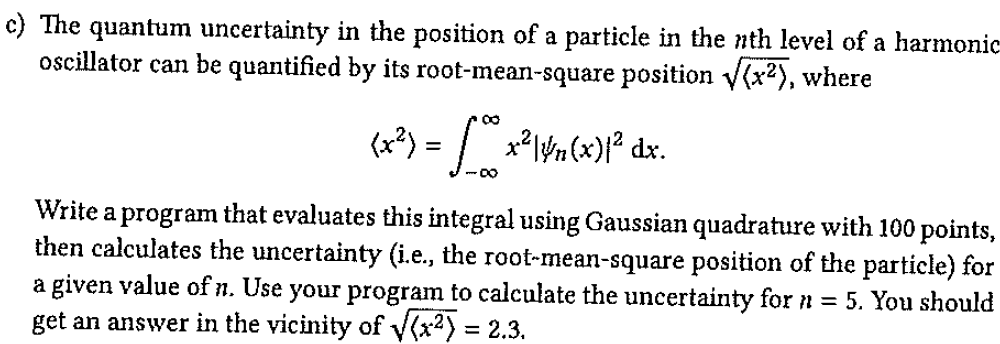

In [11]:
from IPython.display import Image, display
display(Image("G:\\My Drive\\Classes\\Ph322\\2026\\Homework\\Figures\\ex5.13_partc.png"))

In [1]:
# Enter Exercise 5.13c code 

import numpy as np
import matplotlib.pyplot as plt
from math import lgamma
from gaussxw import gaussxw


def H(n, x):
    if n == 0:
        return 1
    if n == 1:
        return 2*x
    else: 
        return 2*x*H(n-1,x)-2*(n-1)*H(n-2, x)

def psi(n,x):
    log_coeff = -0.5 * (n*np.log(2) + lgamma(n+1) +0.5 * np.log(np.pi))
    coeff = np.exp(log_coeff)
    return coeff * np.exp(-x**2/2) * H(n,x)

def position_psi(n,x):
    return x**2 * np.abs(psi(n,x)) **2 

# We will calculate from -10 to +10 as the exponential decays on either end 
# Therefore there will be minimal contributions on either end of the integral. 

a = -10
b = 10
N = 100 

x,w = gaussxw(N)
xp = 0.5*(b-a)*x + 0.5*(b+a)
wp = 0.5*(b-a)*w

# initialize the sum
s = 0.0

# Estimate integral using quadrature
for k in range(N):
    s += wp[k]*position_psi(5, xp[k])

result = np.sqrt(s)
exact = 2.3

print(f"Using N = {N} the estimate of root mean square of the position is {result:0.3f}.")
print(f"The approximation error is {100*abs(exact-result)/exact:.2e}%.")
    

Using N = 100 the estimate of root mean square of the position is 2.345.
The approximation error is 1.97e+00%.


**Pts /10**

In [ ]:
print("Hello")

#### Problem 2 Total Pts /25

### Problem 3 Gauss's Law
This is Exercise 5.20 in the second edition of the textbook. If images do not show either consult the textbook or view the PDF of the problem on Canvas in the Homework module.  


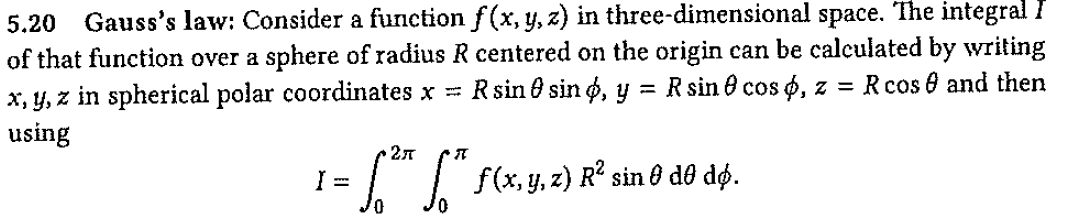

In [13]:
from IPython.display import Image, display
display(Image("G:\\My Drive\\Classes\\Ph322\\2026\\Homework\\Figures\\ex5.20_intro.png"))

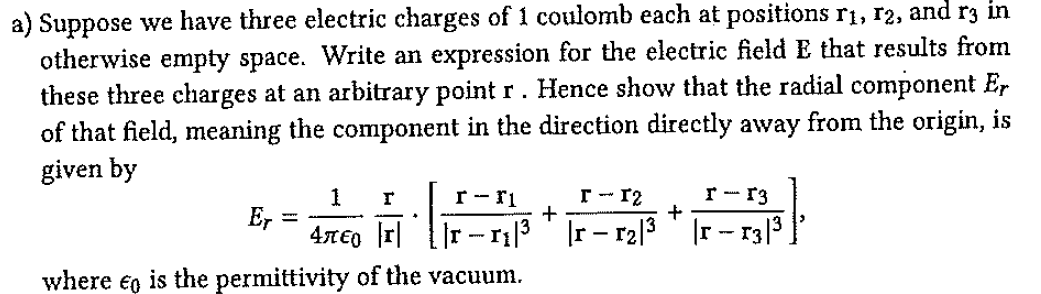

In [ ]:
from IPython.display import Image, display
display(Image("G:\\My Drive\\Classes\\Ph322\\2026\\Homework\\Figures\\ex5.20_part1.png"))

#### Solution

The Electric field at position $r$ from the origin for some charge $Q = 1 C$ at the position $r^*$ is given by:

$$
\vec{E}(r) = \frac{Q}{4 \pi \epsilon_0}  \frac{1}{r'^2}  \hat{r'}
$$

See that $r' = r - r^*$ and $\hat{r'}$ is the norm vector of $r'$. If we were to expand this we have:

$$
\vec{E}(r) = \frac{1}{4 \pi \epsilon_0}  \frac{1}{|r - r^*|^2} \frac{r-r^*}{|r-r^*|}
$$
$$
\vec{E}(r) = \frac{1}{4 \pi \epsilon_0}  \frac{r -r^*}{|r - r^*|^3}
$$

For three point charges at positions $r_1$, $r_2$ and $r_3$, owing to super position we can all all three electric field to gives us:

$$
\vec{E}(r) = \frac{1}{4 \pi \epsilon_0}  \Big [ \frac{r -r_1}{|r - r_1|^3} + \frac{r -r_2}{|r - r_2|^3} + \frac{r -r_3}{|r - r_3|^3} \Big]
$$

Finally, see that the radial vector at some position $r$ from the origin is: 
$$
\vec{r} = \frac{r}{|r|}
$$
Therefore the radial component of the electric field is the dot product of the radial vector with the electric field at position $r$ for all three point charges. 

Therefore, the radial electric field is: 

$$
E_r(r) =   \frac{1}{4 \pi \epsilon_0} \frac{r}{|r|} \cdot \Big [ \frac{r -r_1}{|r - r_1|^3} + \frac{r -r_2}{|r - r_2|^3} + \frac{r -r_3}{|r - r_3|^3} \Big]
$$


**Pts /5**

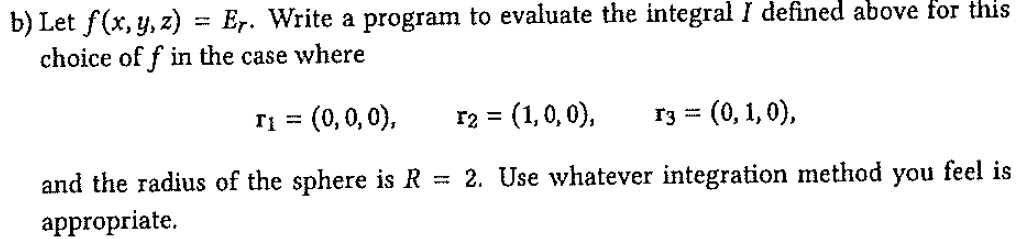

In [15]:
from IPython.display import Image, display
display(Image("G:\\My Drive\\Classes\\Ph322\\2026\\Homework\\Figures\\ex5.20_partb.png"))

Have your program output the integral $I$. 

In [8]:
# Enter Exercise 5.20b code here
import numpy as np
from traitlets import Int
from scipy.constants import epsilon_0
from gaussxw import gaussxw

# x = r sin(theta) cos(phi)
# y = r sin(theta) sin(phi)
# z = r cos(theta)

def r_spherical(r, theta, phi):
    x = r * np.sin(theta) * np.cos(phi)
    y = r * np.sin(theta) * np.sin(phi)
    z = r * np.cos(theta)
    return np.array([x,y,z])

def E_r(r, theta, phi):

    r_1 = np.array([0,0,0])
    r_2 = np.array([1,0,0])
    r_3 = np.array([0,1,0])

    r_vec = r_spherical(r, theta, phi)
    r_vec_norm = r_vec / np.linalg.norm(r_vec)

    r_1_vec = (r_vec - r_1) / (np.linalg.norm(r_vec - r_1))**3
    r_2_vec = (r_vec - r_2) / (np.linalg.norm(r_vec - r_2))**3
    r_3_vec = (r_vec - r_3) / (np.linalg.norm(r_vec - r_3))**3
    
    r_charges = r_1_vec + r_2_vec + r_3_vec

    E_val = 1/(4 * np.pi * epsilon_0) * np.dot(r_vec_norm, r_charges)
    
    return E_val
    

def Int_E():

    R = 2
    N = 100

    # We will use Guassian Quadratures
    
    x, w = gaussxw(N)

    theta_pts = 0.5*(np.pi)*x + 0.5*(np.pi)
    theta_wts = 0.5*(np.pi)*w
    
    phi_pts = (np.pi)*x + (np.pi) 
    phi_wts = np.pi*w 

    # initialize the sum
    s = 0.0

    # Estimate integral using quadrature
    for k in range(N):
        for j in range(N):
            s += theta_wts[k]*phi_wts[j]*E_r(2, theta_pts[k], phi_pts[j])*R**2*np.sin(theta_pts[k])
    
    return s
    
int_val = Int_E() 

print("Guasian Integral: ", int_val)

Guasian Integral:  338822719982.3041


**Pts /10**

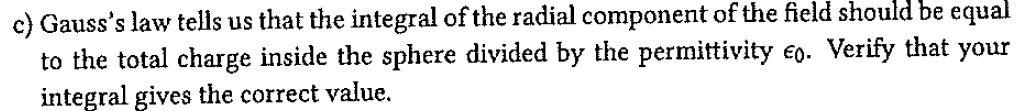

In [19]:
from IPython.display import Image, display
display(Image("G:\\My Drive\\Classes\\Ph322\\2026\\Homework\\Figures\\ex5.20_partc.png"))

In [10]:
from scipy.constants import epsilon_0
print(3 / epsilon_0)

338822719982.3041


**Your estimate of $I$: 338822719982.3 $N \cdot m^2 / C$**

**Total charge divided by $\epsilon_0$: **
$$
I = Q / \epsilon_0 = 338822719982.3041 \ N\cdot m^2 / C
$$

**Pts /5**

#### Problem 3 Pts /20

### Problem 4 Gravitational pull of a uniform sheet
This is Exercise 5.14 in both editions. 

A uniform square sheet of metal is floating motionless in space (check your textbook for an image representation). The sheet is $10$ m on a side and of negligible thickness, and it has a mass of 10 metric tonnes.

**a)** Consider the gravitational force due to the plate felt by a point
  mass of $1$ kg a distance $z$ from the center of the square, in the
  direction perpendicular to the sheet, as shown above.  Show that the
  component of the force along the $z$-axis is
  
\begin{equation*}
F_z = G\sigma z \iint_{-L/2}^{L/2} {d x\,d y\over(x^2+y^2+z^2)^{3/2}}\,,
\end{equation*}

where
$G=6.674\times10^{-11}\,\mathrm{m}^3\,\mathrm{kg}^{-1}\,\mathrm{s}^{-2}$ is
Newton's gravitational constant and $\sigma$ is the mass per unit area of
the sheet.

Type your answer here or insert an image

**Pts /5**

**b)** Write a program to calculate and plot the force as a function of $z$
  from $z=0$ to $z=10$ m.  For the double integral use (double) Gaussian
  quadrature with 100 sample points along each axis.

In [ ]:
import numpy as np
from traitlets import Int
from scipy.constants import epsilon_0
from gaussxw import gaussxw

def func(x,y,z):
    return 1/(x**2 + y**2 + z**2)**(3/2) 

def Int_func():

    z_1 = 0
    z_2 = 10
    a = -5
    b = 5
    
    N = 100

    # We will use Guassian Quadratures
    
    x, w = gaussxw(N)

    x_pts = 0.5*(b-a)*x + 0.5*(b-a)
    x_wts = 0.5*(b-a)*w
    
    y_pts = 0.5*(b-a)*x + 0.5*(b-a)
    y_wts = 0.5*(b-a)*w

    # initialize the sum
    s_1 = 0.0

    # Estimate integral using quadrature
    for k in range(N):
        for j in range(N):
            s_1 += x_wts[k]*y_wts[j]*func(x_pts[k], y_pts[j], z_1)
    
    print(s_1)

    # initialize the sum
    s_2 = 0.0

    # Estimate integral using quadrature
    for k in range(N):
        for j in range(N):
            s_2 += x_wts[k]*y_wts[j]*func(x_pts[k], y_pts[j], z_2)
    
    print(s_2)
    
int_val = Int_func() 

print("Integral Value: ", int_val)

**Pts /10**

#### Problem 4 Pts /15

### Total HW Pts /80